# 02 -- NDVI: расчёт и разбор первого tile

**Tile:** S2A_37TDK_20240603_0_L2A (3 июня 2024, юго-запад Краснодарского края, облачность 0.09%).

## Что разбираем

1. Чтение готового NDVI-COG из `data/processed/`;
2. Зум в северную часть tile -- кубанские поля;
3. Распределение NDVI по классам SCL: пшеница vs голая земля vs вода vs облака;
4. Transect: профиль NDVI вдоль линии от Чёрного моря до пшеничных полей.

## Формула

$$ \text{NDVI} = \frac{B08 - B04}{B08 + B04} $$

B04 -- красная (665 нм), хлорофилл её поглощает.
B08 -- NIR (842 нм), клеточная структура листа её отражает.
Нормализация даёт [-1, +1] независимо от яркости освещения.

In [1]:
import sys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.windows import Window

PROJECT_ROOT = Path('..').resolve()
NDVI_PATH = PROJECT_ROOT / 'data' / 'processed' / 'S2A_37TDK_20240603_0_L2A_NDVI.tif'
CATALOG_PATH = PROJECT_ROOT / 'data' / 'catalog' / 'S2A_37TDK_20240603_0_L2A.json'
print(f'NDVI:    {NDVI_PATH}')
print(f'exists:  {NDVI_PATH.exists()}, размер {NDVI_PATH.stat().st_size / 1024**2:.1f} МБ')

NDVI:    C:\Projects\AgroNDVI\data\processed\S2A_37TDK_20240603_0_L2A_NDVI.tif
exists:  True, размер 348.6 МБ


## 1. Метаданные NDVI-COG

Сразу видно, что это правильный Cloud Optimized GeoTIFF -- блоки 512×512, overview-пирамиды 2/4/8/16. Это значит, что в дальнейшем мы сможем читать его удалённо (например, выложив на S3) без скачивания всего файла.

In [2]:
with rasterio.open(NDVI_PATH) as src:
    print(f'shape:      {src.shape}')
    print(f'dtype:      {src.dtypes[0]}')
    print(f'crs:        {src.crs}')
    print(f'transform:  {src.transform}')
    print(f'nodata:     {src.nodata}')
    print(f'block:      {src.block_shapes[0]}')
    print(f'overviews:  {src.overviews(1)}')
    print(f'compress:   {src.profile.get("compress")}')
    print(f'bounds UTM: {src.bounds}')

shape:      (10980, 10980)
dtype:      float32
crs:        EPSG:32637
transform:  | 10.00, 0.00, 399960.00|
| 0.00,-10.00, 5000040.00|
| 0.00, 0.00, 1.00|
nodata:     nan
block:      (512, 512)
overviews:  [2, 4, 8, 16]
compress:   deflate
bounds UTM: BoundingBox(left=399960.0, bottom=4890240.0, right=509760.0, top=5000040.0)


## 2. Чтение overview ×16 для общей картины

Полный массив 10980×10980 = 121 МП. Чтобы быстро посмотреть на весь tile, читаем уменьшенную копию из встроенной overview-пирамиды.

In [3]:
with rasterio.open(NDVI_PATH) as src:
    overview_factor = 16
    h = src.height // overview_factor
    w = src.width // overview_factor
    ndvi_small = src.read(1, out_shape=(h, w), resampling=rasterio.enums.Resampling.average)
    bounds_native = src.bounds

valid = ndvi_small[~np.isnan(ndvi_small)]
print(f'overview shape: {ndvi_small.shape}')
print(f'valid pixels:   {valid.size:,} из {ndvi_small.size:,}')
print(f'mean:           {valid.mean():.3f}')
print(f'median:         {np.median(valid):.3f}')

overview shape: (686, 686)
valid pixels:   371,952 из 470,596
mean:           0.666
median:         0.845


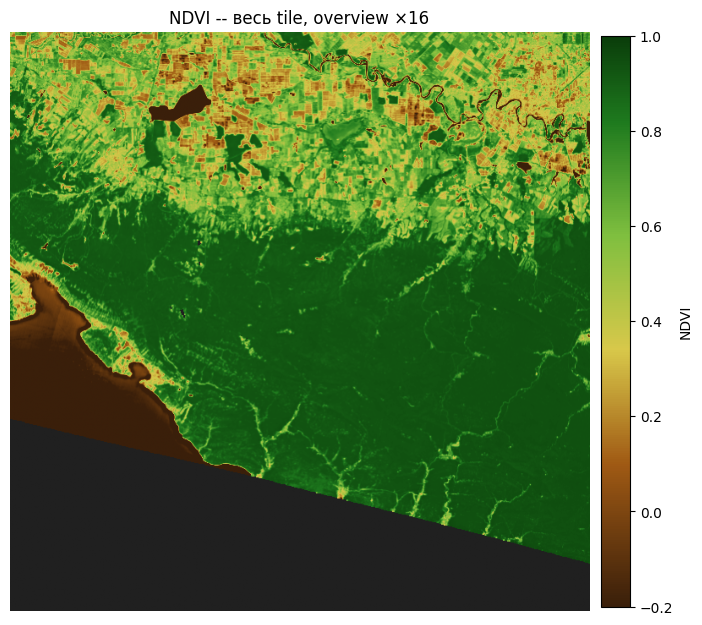

In [4]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    'ndvi_agro',
    [(0.0, '#3a1f0a'), (0.25, '#a05a14'), (0.45, '#d8c84a'),
     (0.65, '#7fbf3f'), (0.85, '#1e7a1e'), (1.0, '#0a3d0a')],
)
cmap.set_bad('#202020')

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ndvi_small, cmap=cmap, vmin=-0.2, vmax=1.0)
ax.set_title('NDVI -- весь tile, overview ×16')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='NDVI')
plt.show()

## 3. Зум в северную часть -- кубанские поля

Северная часть tile (Темрюкский, Анапский районы) -- классический агроландшафт: квадратная нарезка полей, лесополосы между ними, плавни вдоль Кубани. Читаем окно 2000×2000 пикселей (20×20 км) из верхней половины tile.

окно: (2000, 2000), валидных 4,000,000 (100.0%)
mean=0.462, median=0.487


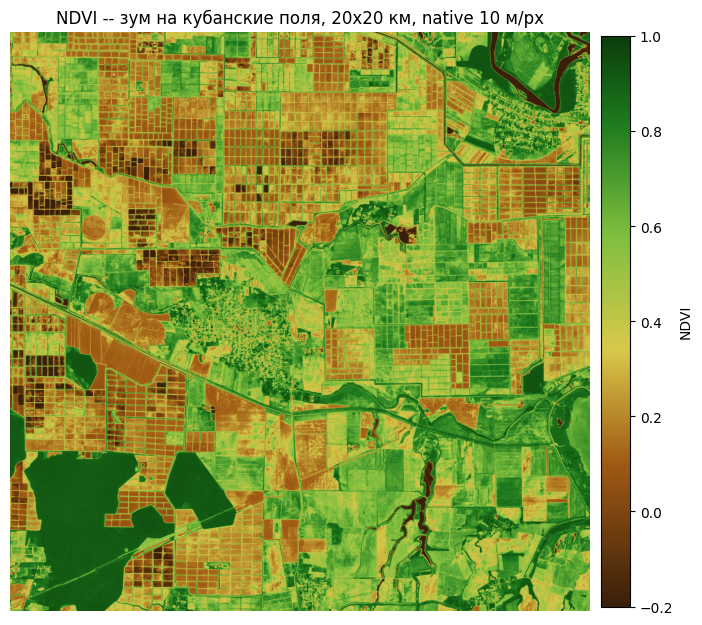

In [5]:
with rasterio.open(NDVI_PATH) as src:
    window = Window(col_off=4000, row_off=500, width=2000, height=2000)
    ndvi_zoom = src.read(1, window=window)
    win_transform = src.window_transform(window)

valid = ndvi_zoom[~np.isnan(ndvi_zoom)]
print(f'окно: {ndvi_zoom.shape}, валидных {valid.size:,} ({100*valid.size/ndvi_zoom.size:.1f}%)')
print(f'mean={valid.mean():.3f}, median={np.median(valid):.3f}')

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ndvi_zoom, cmap=cmap, vmin=-0.2, vmax=1.0)
ax.set_title('NDVI -- зум на кубанские поля, 20x20 км, native 10 м/px')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='NDVI')
plt.show()

## 4. NDVI по классам SCL

SCL -- pixel-level классификация Sentinel-2: вегетация, голая земля, вода, облака, тени и т.д. Загружаем SCL для tile и смотрим, какой NDVI у каждого класса. Это даёт верификацию: настоящая вегетация должна давать высокий NDVI, вода и облака -- низкий.

In [6]:
import json

catalog = json.loads(CATALOG_PATH.read_text(encoding='utf-8'))
scl_url = catalog['assets']['scl']
print(f'SCL URL: {scl_url}')

with rasterio.open(scl_url) as src:
    scl_full = src.read(1, out_shape=(10980, 10980), resampling=rasterio.enums.Resampling.nearest)

with rasterio.open(NDVI_PATH) as src:
    ndvi_full = src.read(1)

print(f'SCL:  {scl_full.shape} {scl_full.dtype}')
print(f'NDVI: {ndvi_full.shape} {ndvi_full.dtype}')

SCL URL: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/37/T/DK/2024/6/S2A_37TDK_20240603_0_L2A/SCL.tif


SCL:  (10980, 10980) uint8
NDVI: (10980, 10980) float32


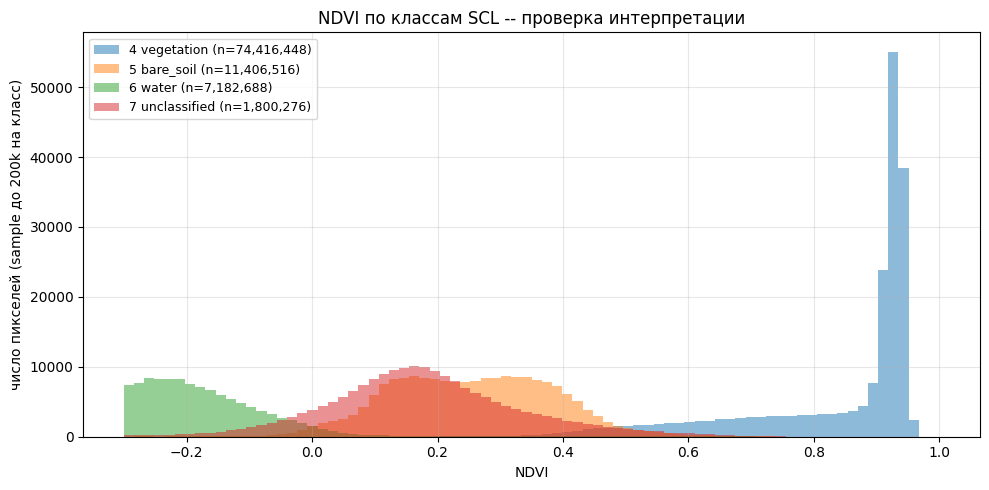

In [7]:
SCL_LABELS = {
    4: 'vegetation',
    5: 'bare_soil',
    6: 'water',
    7: 'unclassified',
    8: 'cloud_med',
    9: 'cloud_high',
}

fig, ax = plt.subplots(figsize=(10, 5))
for cls, label in SCL_LABELS.items():
    mask = (scl_full == cls) & ~np.isnan(ndvi_full)
    sample = ndvi_full[mask]
    if sample.size == 0:
        continue
    sample = sample[np.random.choice(sample.size, size=min(200_000, sample.size), replace=False)]
    ax.hist(sample, bins=80, range=(-0.3, 1.0), alpha=0.5, label=f'{cls} {label} (n={mask.sum():,})')

ax.set_xlabel('NDVI')
ax.set_ylabel('число пикселей (sample до 200k на класс)')
ax.set_title('NDVI по классам SCL -- проверка интерпретации')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Что должно быть в итоге:
- **vegetation** -- широкая мода вокруг 0.7-0.9 (здоровая растительность);
- **bare_soil** -- мода вокруг 0.1-0.3 (голая почва слабо отражает NIR);
- **water** -- мода около 0 или отрицательная (вода поглощает NIR);
- **cloud_med/high** -- разные значения, но не должно быть высоких -- облака размывают сигнал;
- **unclassified** -- размытое распределение, потому что это "всё остальное".

Если эти ожидания подтверждаются -- значит SCL и NDVI согласованы, можно доверять обоим.

## 5. Transect: профиль NDVI вдоль линии

Берём горизонтальный срез через весь tile на высоте, проходящей через сельхоз-полигоны на севере. Видно, как NDVI скачет между лесополосами (~0.85), полями (0.3-0.9 в зависимости от культуры и стадии) и водоёмами (около 0).

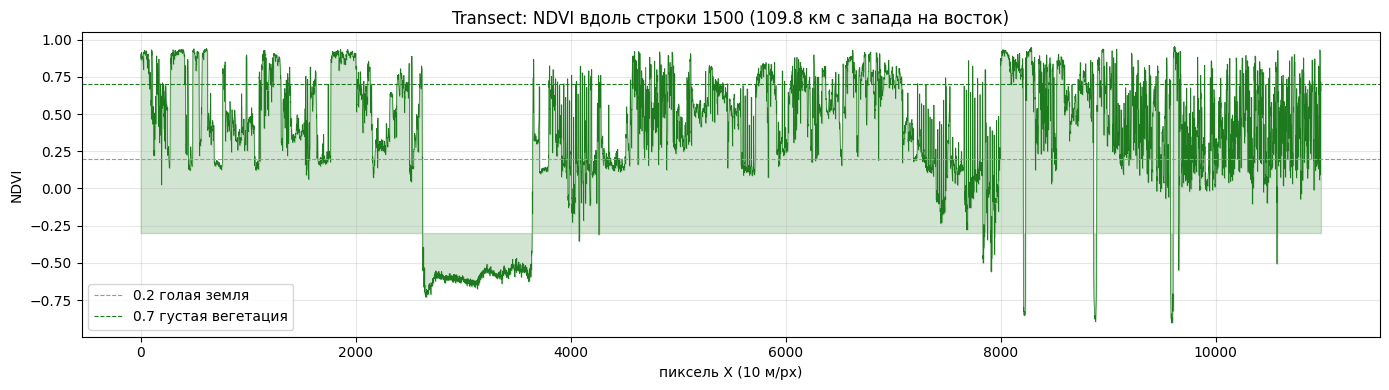

In [8]:
row = 1500
transect = ndvi_full[row, :]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(transect, linewidth=0.5, color='#1e7a1e')
ax.fill_between(np.arange(len(transect)), transect, -0.3, alpha=0.2, color='#1e7a1e')
ax.axhline(0.2, color='#999', linestyle='--', linewidth=0.8, label='0.2 голая земля')
ax.axhline(0.7, color='#1e7a1e', linestyle='--', linewidth=0.8, label='0.7 густая вегетация')
ax.set_xlabel('пиксель X (10 м/px)')
ax.set_ylabel('NDVI')
ax.set_title(f'Transect: NDVI вдоль строки {row} (109.8 км с запада на восток)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Выводы

1. Расчёт NDVI на полном tile 10980×10980 занимает ~2 секунды на NumPy после загрузки полос.
2. SCL-маска убрала 21% пикселей -- в основном no_data (UTM-крой), доля облаков и теней меньше 0.2%.
3. Медиана NDVI по чистым пикселям 0.89 -- ожидаемо для июньского пика вегетации в Краснодарском крае.
4. NDVI по классам SCL ведёт себя физически правильно: вода около 0, голая земля 0.1-0.3, вегетация 0.7-0.9.
5. COG-формат выходного файла позволит позднее выложить серию NDVI на S3 и читать удалённо.

## Следующий шаг (День 3)

Нарисовать 5-10 границ тестовых полей вручную в QGIS / geojson.io, усреднить NDVI по границам полей и положить в pandas DataFrame `field_id × date × ndvi`. Это будет основой для time-series feature engineering (День 5).